In [424]:
import pandas as pd
import numpy as np
import os
import re
def map_geneID(gene_list):
    gff_file = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()),'metadata','gffFile_combined.gff'), sep='\t', comment='#', header=None)
    gene_ID={}
    for i in range(len(gff_file)):
        if gff_file.iloc[i,2]=='gene':
            attributes=gff_file.iloc[i,8]
            # 1. Extract the primary official name
            # 1. Extract 'gene'
            # Looks for 'gene=' and captures any character that is NOT a semicolon [^;]+
            gene_match = re.search(r'Name=([^;]+)', attributes)
            gene = gene_match.group(1) if gene_match else None

            # 2. Extract 'locus_tag'
            # Looks for 'locus_tag=' and captures any character that is NOT a semicolon [^;]+
            locus_match = re.search(r'locus_tag=([^;]+)', attributes)
            locus_tag = locus_match.group(1) if locus_match else None
            gene_ID[locus_tag]=gene
    mapped_genes = []
    for gene in gene_list:
        try:
            mapped_genes.append(gene_ID[gene])
        except KeyError:
            mapped_genes.append(gene)
    return mapped_genes


def get_gene_synonyms():
    gtf_file = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()),'metadata','genomic.gtf'), sep='\t', comment='#', header=None)
    gene_synonyms={}
    for i in range(len(gtf_file)):
        if gtf_file.iloc[i,2]=='gene':
            attributes=gtf_file.iloc[i,8]
            # 1. Extract the primary official name
            gene_match = re.search(r'gene "([^"]+)"', attributes)

            if gene_match:
                primary_gene = gene_match.group(1)   # This is "thrA"

                # 2. Extract ALL synonyms as a temporary list
                # findall returns: ['ECK0002', 'Hs', 'thrA1', 'thrA2']
                synonym_list = re.findall(r'gene_synonym "([^"]+)"', attributes)

                # 3. Loop through the list and map EACH one individually to the primary name
                for syn in synonym_list:
                    gene_synonyms[syn] = primary_gene  # e.g., gene_synonyms["Hs"] = "thrA"
    return gene_synonyms


def standardize_gene(gene_name, mapping_dict):
    # .get() looks for the synonym; if it doesn't find it, it returns the original name
    return mapping_dict.get(gene_name, gene_name)


def map_gene_names(bulk_genes, sc_genes):
    # Convert arr2 to a set for O(1) lookups
    # Find genes unique to each dataset
    only_in_bulk = list(set(bulk_genes) - set(sc_genes))
    only_in_sc = list(set(sc_genes) - set(bulk_genes))
    print(f"Unmatched bulk genes before mapping: {len(only_in_bulk)}")
    print(f"Unmatched single-cell genes before mapping: {len(only_in_sc)}")
    bulk_genes = map_geneID(bulk_genes)
    sc_genes = [s.replace('LELOBEKK_','') for s in sc_genes]
    # get gene synonyms dict
    gene_synonyms = get_gene_synonyms()
    # 1. Convert every gene in both lists to its official canonical name
    standardized_bulk = [standardize_gene(g, gene_synonyms) for g in bulk_genes]
    standardized_sc = [standardize_gene(g, gene_synonyms) for g in sc_genes]
    only_in_bulk = list(set(standardized_bulk) - set(standardized_sc))
    only_in_sc = list(set(standardized_sc) - set(standardized_bulk))
    print(f"Unmatched bulk genes after mapping: {len(only_in_bulk)}")
    print(f"Unmatched single-cell genes after mapping: {len(only_in_sc)}")
    return standardized_bulk, standardized_sc


bulk_data = pd.read_excel(r'C:\Users\owner\Documents\Projects\dysregulated-persistence\bulk_data\All bulk data.xlsx', index_col=0)
bulk_data = bulk_data.iloc[:, 11:16]
sc_data = pd.read_csv(r"C:\Users\owner\Documents\Projects\dysregulated-persistence\data_for_paper\sample_15a_filtered.csv", index_col=0)
bulk_genes = bulk_data.index.tolist()
sc_genes = sc_data.columns.tolist()

bulk_mapped, sc_mapped = map_gene_names(bulk_genes, sc_genes)
# Convert both to lowercase sets
set1 = {s.lower() for s in bulk_mapped}
set2 = {s.lower() for s in sc_mapped}

# Find the intersection
intersection = list(set1 & set2)
common_genes = np.unique(intersection)
correlation_data = pd.DataFrame(index=common_genes)
aggregated_sc = pd.DataFrame(index=sc_genes)
aggregated_sc['mapped_genes'] = [s.lower() for s in sc_mapped]
aggregated_sc['counts'] = np.mean(sc_data,axis=0).tolist()
bulk_avg = pd.DataFrame(index=bulk_genes)
bulk_avg['mapped_genes'] = [s.lower() for s in bulk_mapped]
bulk_avg['counts'] = np.mean(bulk_data.iloc[:,1:6],axis=1).tolist()
correlation_data['bulk']=np.zeros(len(common_genes))
correlation_data['single-cell']=np.zeros(len(common_genes))
for i in range(len(aggregated_sc)):
    if aggregated_sc['mapped_genes'][i] in correlation_data.index:
        correlation_data.loc[aggregated_sc['mapped_genes'][i],'single-cell'] += aggregated_sc.iloc[i,1]
for i in range(len(bulk_avg)):
    if bulk_avg['mapped_genes'][i] in correlation_data.index:
        correlation_data.loc[bulk_avg['mapped_genes'][i],'bulk'] += bulk_avg.iloc[i,1]

Unmatched bulk genes before mapping: 2704
Unmatched single-cell genes before mapping: 424
Unmatched bulk genes after mapping: 2343
Unmatched single-cell genes after mapping: 135


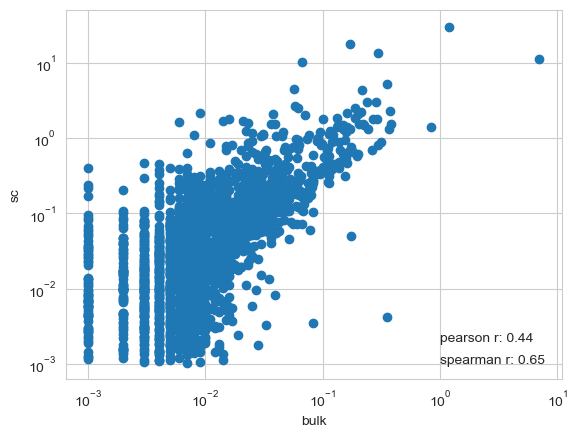

PearsonRResult(statistic=0.43695489668370313, pvalue=1.5536568379061435e-87)
SignificanceResult(statistic=0.6517347436504596, pvalue=2.980135989513207e-225)


In [425]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
x = correlation_data['single-cell']
y = correlation_data['bulk']
x = x[y>1e-3]
y = y[y>1e-3]
plt.scatter(x,y)
plt.xscale('log')
plt.yscale('log')
r,p = pearsonr(x,y)
s, p_s = spearmanr(x,y)
plt.text(1,2e-3,f'pearson r: {r:.2f}')
plt.text(1,1e-3,f'spearman r: {s:.2f}')
plt.xlabel('bulk')
plt.ylabel('sc')
plt.show()
print(pearsonr(x,y))
print(spearmanr(x,y))

In [426]:
correlation_data

,bulk,single-cell
aaea,0.010174,0.007
aaeb,0.010736,0.003
aaer,0.037969,0.011
aas,0.021575,0.007
abpb,0.006233,0.007
...,...,...
znub,0.022409,0.004
znuc,0.018594,0.004
zrap,0.001206,0.000
zupt,0.117212,0.006
